In [ ]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 

In [62]:
# First - Importing DataSet 

df=pd.read_csv('../datasets/Customer_Churn_Prediction.csv')

# Showing Sample 

df.sample(2)




,Customer_ID,Age,Gender,Region,Employment_Status,Education_Level,Tenure_Months,Contract_Type,Customer_Segment,Payment_Method,...,Monthly_Income,Credit_Score,Avg_Monthly_Usage_GB,Num_Support_Calls,Satisfaction_Score,Num_Products_Purchased,Avg_Transaction_Amount,Late_Payment_Count,Days_Since_Last_Login,Churn
1516,CUST101514,21.0,Female,North,NaN,NaN,46.0,Month-to-Month,Individual,Credit Card,...,2949.56,616.0,17.64,1.0,8.0,1,82.36,0.0,NaN,Yes
109,CUST100977,36.0,Male,Central,Employed,Master,6.0,Month-to-Month,Family,Electronic Check,...,8879.01,657.0,27.24,0.0,9.0,5,121.14,0.0,31.0,No


In [32]:
df.shape # (2010, 23)
df.isnull().sum()

percentage_null = (df.isnull().sum() / len(df)) * 100

percentage_null.sort_values(ascending=False)
# print(percentage_null) 

# df.duplicated().sum() # 10
df.duplicated().value_counts() 

# df.info()

df['Churn'].value_counts('Yes')*100

Churn
No     70.049751
Yes    29.950249
Name: proportion, dtype: float64

In [ ]:
df.drop_duplicates(inplace=True) # removing the suplicates 

In [24]:
df.describe()

,Age,Tenure_Months,Monthly_Charges,Total_Charges,Annual_Income,Monthly_Income,Credit_Score,Avg_Monthly_Usage_GB,Num_Support_Calls,Satisfaction_Score,Num_Products_Purchased,Avg_Transaction_Amount,Late_Payment_Count,Days_Since_Last_Login
count,1970.000000,2010.000000,2010.000000,1979.000000,1.889000e+03,1910.000000,1950.000000,1930.000000,1970.000000,1870.000000,2010.000000,2010.000000,2010.000000,1930.000000
mean,40.526904,27.022388,81.288960,2148.779192,5.471024e+04,4395.738487,682.451282,44.422710,2.302538,7.978610,2.037313,123.756527,0.930846,14.843005
std,12.378266,18.045129,30.862535,1611.659431,4.803766e+04,2667.058035,74.173001,26.590025,3.067191,1.054721,1.261720,778.489622,0.982015,13.868400
min,0.000000,-12.000000,-49.990000,12.040000,1.200000e+04,963.030000,415.000000,3.320000,0.000000,5.000000,1.000000,5.000000,0.000000,0.000000
25%,32.000000,13.000000,62.632500,970.855000,3.059819e+04,2551.570000,633.000000,24.982500,1.000000,7.000000,1.000000,29.870000,0.000000,5.000000
50%,41.000000,23.000000,78.400000,1741.610000,4.458343e+04,3727.170000,684.000000,38.870000,2.000000,8.000000,2.000000,52.280000,1.000000,11.000000
75%,48.000000,37.000000,96.252500,2852.065000,6.646092e+04,5475.657500,730.000000,57.362500,3.000000,9.000000,3.000000,88.380000,1.000000,21.000000
max,187.000000,72.000000,419.470000,11683.280000,1.200000e+06,26527.370000,999.000000,217.760000,29.000000,10.000000,8.000000,21000.000000,6.000000,112.000000


In [31]:
num_cols = df.select_dtypes(include='number').columns



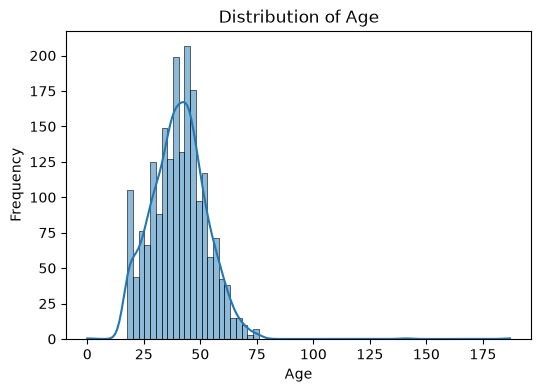

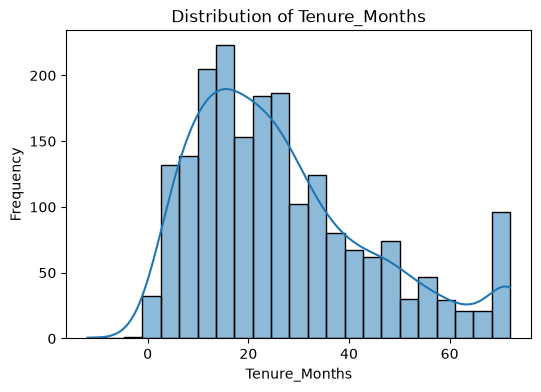

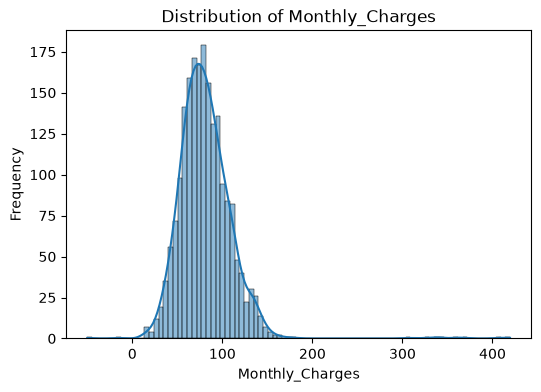

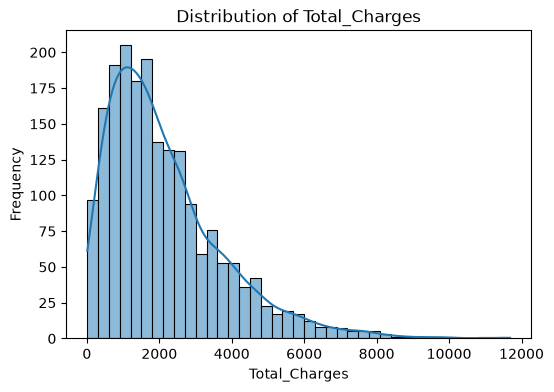

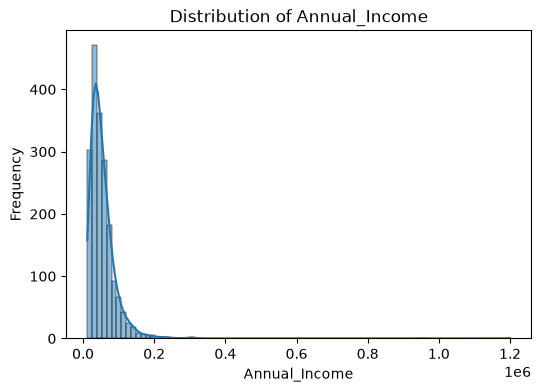

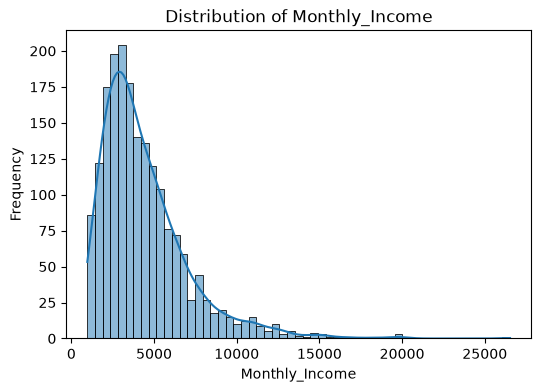

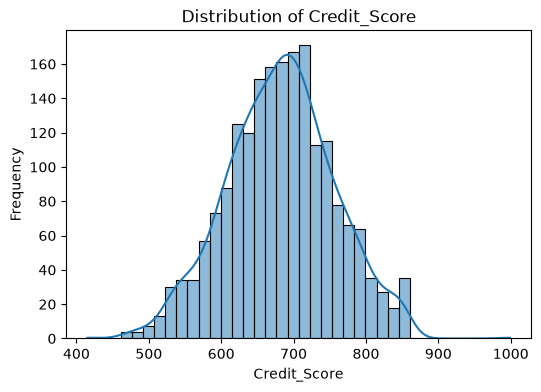

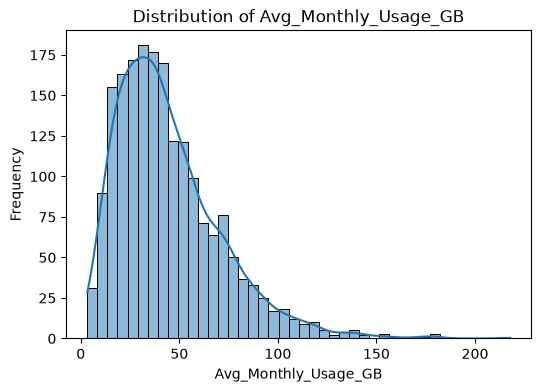

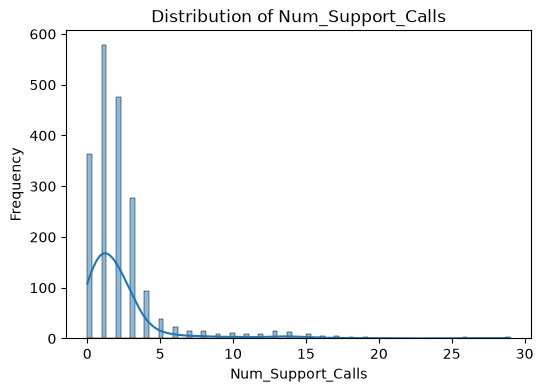

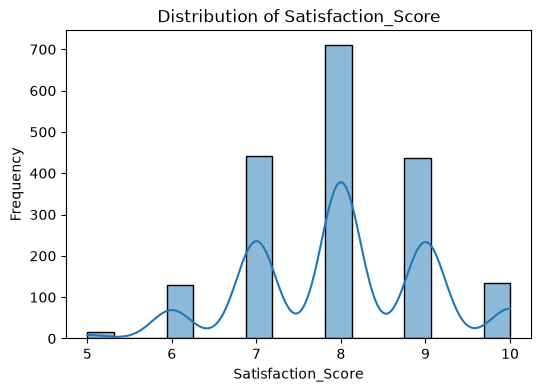

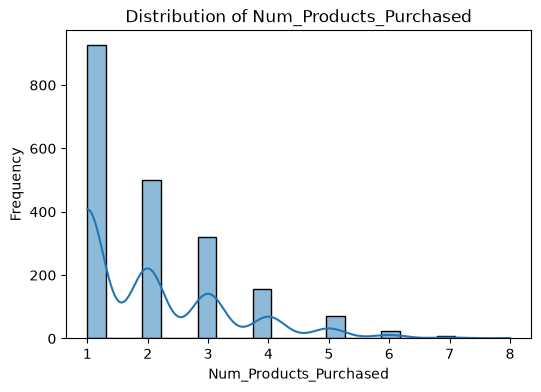

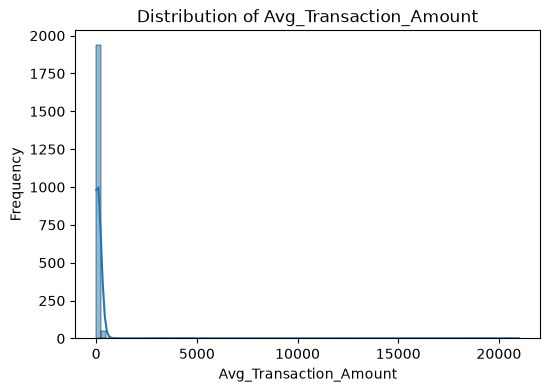

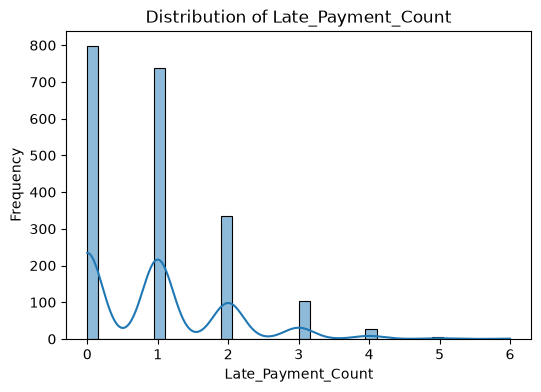

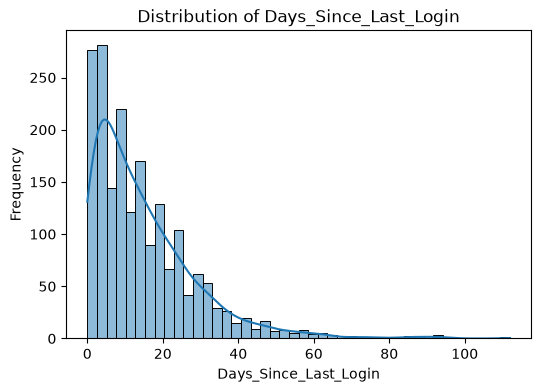

In [28]:
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col],kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()
    
    


In [30]:
df.select_dtypes(include='number').skew().sort_values(ascending=False)

Avg_Transaction_Amount    20.097368
Annual_Income             11.458146
Num_Support_Calls          3.787361
Monthly_Charges            3.125652
Monthly_Income             1.947744
Days_Since_Last_Login      1.913356
Total_Charges              1.446105
Avg_Monthly_Usage_GB       1.336011
Num_Products_Purchased     1.327362
Age                        1.173283
Late_Payment_Count         1.136242
Tenure_Months              0.889015
Credit_Score              -0.026299
Satisfaction_Score        -0.116207
dtype: float64

In [34]:
# dropping Useless Column 
df.drop(columns=['Customer_ID'],inplace=True)

In [35]:
df.sample(1)

,Age,Gender,Region,Employment_Status,Education_Level,Tenure_Months,Contract_Type,Customer_Segment,Payment_Method,Monthly_Charges,...,Monthly_Income,Credit_Score,Avg_Monthly_Usage_GB,Num_Support_Calls,Satisfaction_Score,Num_Products_Purchased,Avg_Transaction_Amount,Late_Payment_Count,Days_Since_Last_Login,Churn
1825,53.0,Female,North,Employed,High School,38.0,One-Year,Small Business,Credit Card,60.22,...,3177.7,615.0,38.24,1.0,8.0,1,53.34,2.0,10.0,No


In [ ]:
# extracting X and The Y 
X=df.drop(columns=['Churn'])
Y=df['Churn']


0        No
1        No
2        No
3       Yes
4        No
       ... 
2005     No
2006     No
2007    Yes
2008    Yes
2009    Yes
Name: Churn, Length: 2000, dtype: str


In [45]:
# Step 1: Invalid values ko NaN mein convert karna (domain knowledge based)

df.loc[(df['Age'] < 18) | (df['Age'] > 100), 'Age'] = np.nan

df.loc[df['Tenure_Months'] < 0, 'Tenure_Months'] = np.nan

df.loc[df['Monthly_Charges'] < 0, 'Monthly_Charges'] = np.nan

print(df[['Age', 'Tenure_Months', 'Monthly_Charges']].describe())

               Age  Tenure_Months  Monthly_Charges
count  1957.000000    1997.000000      1998.000000
mean     40.460399      27.064096        81.468048
std      11.685032      17.987858        30.697266
min      18.000000       0.000000        15.000000
25%      32.000000      13.000000        62.760000
50%      41.000000      23.000000        78.505000
75%      48.000000      37.000000        96.425000
max      75.000000      72.000000       419.470000


In [44]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(X,Y,test_size=0.3,random_state=42, stratify=Y)

In [43]:
# Creating CustumCapper IQR for removing the Outlier 

from sklearn.base import BaseEstimator,TransformerMixin

from sklearn.base import BaseEstimator, TransformerMixin

class IQRCapper(BaseEstimator, TransformerMixin):
    def __init__(self, factor=1.5):
        self.factor = factor
        
    def fit(self, X, y=None):
        Q1 = np.percentile(X, 25, axis=0)
        Q3 = np.percentile(X, 75, axis=0)
        
        IQR = Q3 - Q1
        
        self.upperbound = Q3 + self.factor * IQR
        self.lowerbound = Q1 - self.factor * IQR
        
        return self
    
    def transform(self, X):
        return np.clip(X, self.lowerbound, self.upperbound)
        
        


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import PowerTransformer

skew_num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('IQR', IQRCapper()),
    ('transformer', PowerTransformer(method='yeo-johnson')) #  i skip StandardScalar because yeo-johnson method automatically done this
])

In [48]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

simple_num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scalar', StandardScaler())
])

In [49]:
from sklearn.preprocessing import KBinsDiscretizer

age_bin_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),   # Age skewed nahi tha zyada (1.17), lekin invalid values NaN ho chuki hain
    ('binning', KBinsDiscretizer(n_bins=5, strategy='uniform', encode='ordinal'))
])

In [50]:
from sklearn.preprocessing import OneHotEncoder

nominal_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder())
])

In [64]:
from sklearn.preprocessing import OrdinalEncoder

print(df['Education_Level'].unique())
print(df['Contract_Type'].unique())

ordinal_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal_encoder', OrdinalEncoder(
        categories=[
            ['High School', 'Bachelor', 'Master', 'PhD'],      # Education_Level
            ['Month-to-Month', 'One-Year', 'Two-Year']         # Contract_Type
        ]
    ))
])

<StringArray>
['High School', 'Master', nan, 'Bachelor', 'PhD']
Length: 5, dtype: str
<StringArray>
['Month-to-Month', 'One-Year', 'Two-Year']
Length: 3, dtype: str


In [65]:
skewed_num_cols = [
    'Avg_Transaction_Amount',
    'Annual_Income',
    'Num_Support_Calls',
    'Monthly_Charges',
    'Monthly_Income',
    'Days_Since_Last_Login'
]

simple_num_cols = [
    'Total_Charges',
    'Avg_Monthly_Usage_GB',
    'Num_Products_Purchased',
    'Tenure_Months',
    'Late_Payment_Count',
    'Credit_Score',
    'Satisfaction_Score'
]

age_bin_cols = ['Age']

nominal_cols = [
    'Gender',
    'Region',
    'Payment_Method',
    'Customer_Segment',
    'Employment_Status'
]

ordinal_cols = [
    'Education_Level',
    'Contract_Type'
]

In [67]:
from sklearn.compose import ColumnTransformer

preprocess=ColumnTransformer([
    ("skew_num_data",skew_num_pipeline,skewed_num_cols),
    ("num_data",simple_num_pipeline,simple_num_cols),
    ("age_bin_data",age_bin_pipeline,age_bin_cols),
    ('nominal_data',nominal_pipeline,nominal_cols),
    ('ordinal_data',ordinal_pipeline,ordinal_cols)
])

In [72]:
from sklearn.linear_model import LogisticRegression

model = Pipeline([
    ('preprocess', preprocess),
    ('lr', LogisticRegression(class_weight='balanced'))
])


In [73]:
model.fit(x_train, y_train)
y_pred = model.predict(x_train)

from sklearn.metrics import accuracy_score
print(f"Train Accuracy: {accuracy_score(y_train, y_pred)*100:.2f}%")  # .2f means that up to 2 Decimal Places 

Train Accuracy: 75.93%


In [74]:
y_test_pred = model.predict(x_test)
print(f"Test Accuracy: {accuracy_score(y_test, y_test_pred)*100:.2f}%")

Test Accuracy: 80.50%


In [75]:
from sklearn.metrics import confusion_matrix, classification_report

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred))

Confusion Matrix:
[[334  86]
 [ 31 149]]

Classification Report:
              precision    recall  f1-score   support

          No       0.92      0.80      0.85       420
         Yes       0.63      0.83      0.72       180

    accuracy                           0.81       600
   macro avg       0.77      0.81      0.78       600
weighted avg       0.83      0.81      0.81       600



In [76]:
X_train_transformed = preprocess.fit_transform(x_train)
print(X_train_transformed.shape)

(1400, 36)


In [77]:
from sklearn.decomposition import PCA

pca = PCA()
pca.fit(X_train_transformed)

# har component individually kitna variance explain karta hai
print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)

# cumulative variance — kitne components milakar kitna % variance cover hota hai
import numpy as np
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
print("\nCumulative Variance:")
print(cumulative_variance)

Explained Variance Ratio:
[1.48993070e-01 1.08996206e-01 7.24918360e-02 7.07621250e-02
 6.49993194e-02 5.73606799e-02 5.27906892e-02 4.78179228e-02
 4.22334041e-02 4.13355365e-02 3.82127266e-02 3.19544914e-02
 2.64389430e-02 2.35557602e-02 1.91456705e-02 1.81073346e-02
 1.66210674e-02 1.46492697e-02 1.37972580e-02 1.26444263e-02
 1.17503331e-02 1.07991741e-02 1.06753442e-02 9.31727803e-03
 8.33365783e-03 6.39635352e-03 5.52428210e-03 4.29505195e-03
 3.54997227e-03 3.33625583e-03 3.11456107e-03 1.81673054e-17
 2.09353039e-18 0.00000000e+00 0.00000000e+00 0.00000000e+00]

Cumulative Variance:
[0.14899307 0.25798928 0.33048111 0.40124324 0.46624256 0.52360324
 0.57639392 0.62421185 0.66644525 0.70778079 0.74599352 0.77794801
 0.80438695 0.82794271 0.84708838 0.86519571 0.88181678 0.89646605
 0.91026331 0.92290774 0.93465807 0.94545724 0.95613259 0.96544987
 0.97378352 0.98017988 0.98570416 0.98999921 0.99354918 0.99688544
 1.         1.         1.         1.         1.         1.        ]

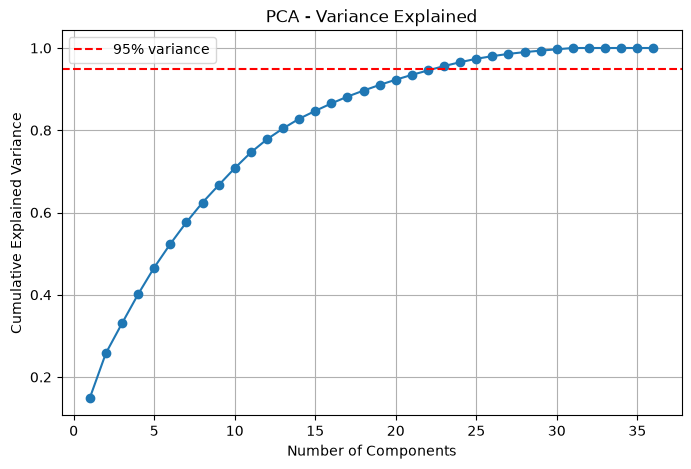

In [78]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance, marker='o')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA - Variance Explained')
plt.legend()
plt.grid(True)
plt.show()

In [79]:
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

model_pca = Pipeline([
    ('preprocess', preprocess),
    ('pca', PCA(n_components=0.95)),
    ('lr', LogisticRegression(class_weight='balanced'))
])

model_pca.fit(x_train, y_train)

y_test_pred_pca = model_pca.predict(x_test)

from sklearn.metrics import classification_report, accuracy_score
print(f"Test Accuracy: {accuracy_score(y_test, y_test_pred_pca)*100:.2f}%")
print(classification_report(y_test, y_test_pred_pca))

Test Accuracy: 80.17%
              precision    recall  f1-score   support

          No       0.92      0.79      0.85       420
         Yes       0.63      0.83      0.72       180

    accuracy                           0.80       600
   macro avg       0.77      0.81      0.78       600
weighted avg       0.83      0.80      0.81       600



In [81]:
from sklearn.metrics import make_scorer, f1_score

f1_yes_scorer = make_scorer(f1_score, pos_label='Yes')

In [93]:
param_grid = {
    'lr__C': [0.01, 0.1, 1, 10, 100],
    'lr__class_weight': ['balanced', None],

    'preprocess__skew_num_data__imputer__strategy': ['mean', 'median'],
    'preprocess__num_data__imputer__strategy': ['mean', 'median'],
    'preprocess__age_bin_data__imputer__strategy': ['mean', 'median'],
    'preprocess__nominal_data__imputer__strategy': ['most_frequent'],   
    'preprocess__ordinal_data__imputer__strategy': ['most_frequent'],   # constant hataya
}

In [94]:
from sklearn.model_selection import GridSearchCV

grid_search = GridSearchCV(
    model,              
    param_grid,
    cv=5,
    scoring=f1_yes_scorer, 
    n_jobs=-1
)

grid_search.fit(x_train, y_train)

print("Best Params:", grid_search.best_params_)
print("Best CV Score:", grid_search.best_score_)

Best Params: {'lr__C': 0.1, 'lr__class_weight': 'balanced', 'preprocess__age_bin_data__imputer__strategy': 'mean', 'preprocess__nominal_data__imputer__strategy': 'most_frequent', 'preprocess__num_data__imputer__strategy': 'mean', 'preprocess__ordinal_data__imputer__strategy': 'most_frequent', 'preprocess__skew_num_data__imputer__strategy': 'mean'}
Best CV Score: 0.6512948524980925


In [87]:
best_model = grid_search.best_estimator_
grid_predictions = best_model.predict(x_test)

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Test Accuracy:", accuracy_score(y_test, grid_predictions))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, grid_predictions))
print("\nClassification Report:")
print(classification_report(y_test, grid_predictions))

Test Accuracy: 0.8016666666666666

Confusion Matrix:
[[333  87]
 [ 32 148]]

Classification Report:
              precision    recall  f1-score   support

          No       0.91      0.79      0.85       420
         Yes       0.63      0.82      0.71       180

    accuracy                           0.80       600
   macro avg       0.77      0.81      0.78       600
weighted avg       0.83      0.80      0.81       600



In [88]:
import pickle

with open('../models/customer_churn_gridsearch_model.pkl', 'wb') as file:
    pickle.dump(best_model, file)

In [89]:
import pickle

with open('../models/customer_churn_gridsearch_model.pkl', 'rb') as file:
    loaded_model = pickle.load(file)

In [90]:
import pandas as pd

new_customer = pd.DataFrame([{
    'Age': 29,
    'Gender': 'Male',
    'Region': 'North',
    'Employment_Status': 'Employed',
    'Education_Level': 'Bachelor',
    'Tenure_Months': 15,
    'Contract_Type': 'Month-to-Month',
    'Customer_Segment': 'Individual',
    'Payment_Method': 'Credit Card',
    'Monthly_Charges': 95.50,
    'Total_Charges': 1432.75,
    'Annual_Income': 52000.00,
    'Monthly_Income': 4333.33,
    'Credit_Score': 690,
    'Avg_Monthly_Usage_GB': 48.5,
    'Num_Support_Calls': 3,
    'Satisfaction_Score': 6,
    'Num_Products_Purchased': 2,
    'Avg_Transaction_Amount': 60.25,
    'Late_Payment_Count': 1,
    'Days_Since_Last_Login': 8
}])

In [92]:
prediction = loaded_model.predict(new_customer)
print("Predicted Churn:", prediction[0])

#probability se check kr rha ka kitna confident ha model result pa 
probability = loaded_model.predict_proba(new_customer)
print("Probability [No, Yes]:", probability[0])

Predicted Churn: Yes
Probability [No, Yes]: [0.28483304 0.71516696]
